Bestimmung des Richtmoments


In [156]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uncertainties as unc

In [157]:
angles = np.array([110, 172, 232, 292, 354, 422])* np.pi/180  # convert to radians
error_angles = np.full(angles.shape, 2)*np.pi/180  # 2 degrees for each angle

masses = np.array([0, 50, 100, 150, 200, 250])*1e-3


In [158]:
func = lambda m, x, b: m * x + b

popt_D, pcov_D = curve_fit(func, masses, angles, sigma=error_angles)

print(rf"Fitted parameters: m = {popt_D[0]:.5f} pm {np.sqrt(pcov_D[0, 0]):.5f}")


Fitted parameters: m = 21.60219 pm 0.22508


<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_4517/3116238039.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x_fit, y_fit, label=f'Fitted line M = {popt_D[0]:.3f} $\pm$ {np.sqrt(pcov_D[0, 0]):.3f}', color='red')


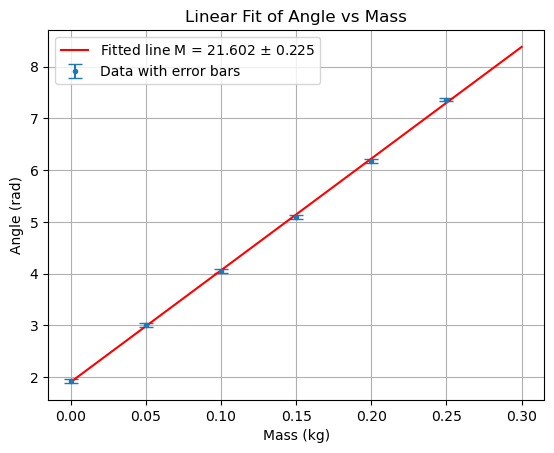

In [159]:
plt.errorbar(masses, angles, yerr=error_angles, fmt='.', label='Data with error bars', capsize=5)
x_fit = np.linspace(0, 0.300, 100)
y_fit = func(x_fit, *popt_D)
plt.plot(x_fit, y_fit, label=f'Fitted line M = {popt_D[0]:.3f} $\pm$ {np.sqrt(pcov_D[0, 0]):.3f}', color='red')

plt.xlabel('Mass (kg)')
plt.ylabel('Angle (rad)')
plt.title('Linear Fit of Angle vs Mass')
plt.legend()
plt.grid()



Richtmoment berechnen

In [160]:
M = unc.ufloat(popt_D[0], np.sqrt(pcov_D[0, 0]))
g = 9.81
r = unc.ufloat(5, 0.005) * 1e-2

D = g * r/M
print(f" D = {D:.3e}")

 D = (2.271+/-0.024)e-02


Aufgabe 2

In [161]:
m_s = unc.ufloat(0.488, 0.001)
r
T_1 = unc.ufloat(1.21, 0.03)
T_2 = unc.ufloat(1.535, 0.025) 

D_period= 2* np.pi**2 * m_s * r**2 / (T_2**2 - T_1**2)
print(f" D über periodendauer = {D_period:.3e}")

 D über periodendauer = (2.699+/-0.320)e-02


A3 Trághetismomment unregelmäßige Platte

J_tisch

In [162]:
J_tisch = D * T_1**2 / (4 * np.pi**2)
print(f" J_tisch = {J_tisch:.3e}")

 J_tisch = (8.421+/-0.427)e-04


In [163]:
T_platte = unc.ufloat(2.355, 0.025)

J_ges = D * T_platte**2 / (4 * np.pi**2)
print(f" J_ges = {J_ges:.3e}")

J_platte = J_ges - J_tisch
print(f" J_platte = {J_platte:.3e}")

 J_ges = (3.190+/-0.076)e-03
 J_platte = (2.348+/-0.083)e-03


Aufgabe 4: trägheitsmomente/steiner

In [164]:
import uncertainties.unumpy as unp

In [165]:
T = np.array([47.1, 47.3, 48.0, 49.0, 51.8, 54.9])/20
err_T = np.full(T.shape, 0.5)/20

a = np.array([0, 5, 10, 20, 30, 40])*1e-3 # abstände
err_a = np.full(a.shape, 1)*1e-3

uncertainties_T = unp.uarray(T, err_T)
uncertainties_a = unp.uarray(a, err_a)


print(f"uncertainties_T = {uncertainties_T}")

J= (D * uncertainties_T**2 / (4 * np.pi**2))-J_tisch

for a_i, J_i in zip(a, J):
    
    print(f"J({a_i * 1e3:.0f} mm) = {J_i:.3e}")

uncertainties_T = [2.355+/-0.025 2.3649999999999998+/-0.025 2.4+/-0.025 2.45+/-0.025
 2.59+/-0.025 2.745+/-0.025]
J(0 mm) = (2.348+/-0.083)e-03
J(5 mm) = (2.375+/-0.084)e-03
J(10 mm) = (2.471+/-0.085)e-03
J(20 mm) = (2.610+/-0.086)e-03
J(30 mm) = (3.016+/-0.091)e-03
J(40 mm) = (3.492+/-0.096)e-03


Plot

Fitted parameters: J_fit = 0.00237 \pm 0.00001$


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_4517/3860058773.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(a**2, func(a, J_platte.nominal_value), label=f'theoretical Steiner line \nJ = {J_platte.nominal_value:.3e} $\pm$ {J_platte.std_dev:.3e}', color='red')
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_4517/3860058773.py:22: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(a**2, func(a, *popt_steiners), label=f'Fitted Steiner line \nJ_s = {popt_steiners[0]:.3e} $\pm$ {np.sqrt(pcov_steiners[0, 0]):.3e}', color='green')


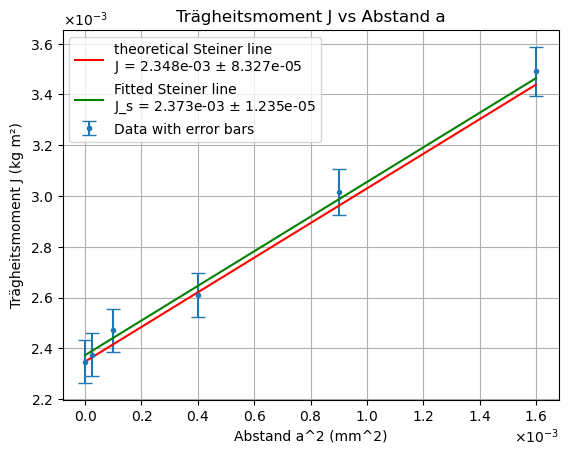

In [185]:

plt.errorbar(a**2 , unp.nominal_values(J), yerr=unp.std_devs(J), fmt='.', label='Data with error bars', capsize=5)
plt.xlabel(f'Abstand a^2 (mm^2)')
plt.ylabel('Trägheitsmoment J (kg m²)')
plt.title('Trägheitsmoment J vs Abstand a')
plt.grid()

# steiner
m_platte = 0.682 

func = lambda d, J_s: J_s + m_platte * d**2

plt.plot(a**2, func(a, J_platte.nominal_value), label=f'theoretical Steiner line \nJ = {J_platte.nominal_value:.3e} $\pm$ {J_platte.std_dev:.3e}', color='red')


ax = plt.gca()
ax.ticklabel_format(axis='both', style='sci', scilimits=(0, 0), useMathText=True)


popt_steiners, pcov_steiners = curve_fit(func, a, unp.nominal_values(J), sigma=unp.std_devs(J))
print(rf"Fitted parameters: J_fit = {popt_steiners[0]:.5f} \pm {np.sqrt(pcov_steiners[0, 0]):.5f}$")

plt.plot(a**2, func(a, *popt_steiners), label=f'Fitted Steiner line \nJ_s = {popt_steiners[0]:.3e} $\pm$ {np.sqrt(pcov_steiners[0, 0]):.3e}', color='green')

plt.legend()